# 03 · Segmentación de mercados
**High Garden Coffee**

**Objetivo:** agrupar los países según su tamaño, dinámica de crecimiento y estabilidad, para poder tratarlos con estrategias distintas en lugar de mirar 51 países por separado.

**Entrada:** `outputs/coffee_long.parquet`
**Salida:** `outputs/segments.parquet`

Este notebook es independiente del pronóstico: usa solo el comportamiento **histórico**.

In [2]:
import sys

# Install scikit-learn in the current notebook kernel
!{sys.executable} -m pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/29/8a/8d1e888fe3d0dd4e2a1f3356dad703eed569aaf673e222b6f647005ad30f/scikit_learn-1.9.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/43/3f/f88a53f60a472b46f4023f56d204dd7de33d34c5d2acbfa0d70a674e639e/threadpoolctl-3.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for cloudpickle>=3.0 from https://files.pythonhosted.org/packages/88/39/799be3f2f0f38cc727ee3b4f1445fe6d5e4133064ec2e4115069418a5bb6/cloudpickle-3.1.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.3 MB 7.3 MB/s eta 0:00:02
   


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

from utils import *

warnings.filterwarnings("ignore", category=DeprecationWarning)  # avisos de pandas por groupby.apply
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.3f}".format

long = load_long()
universe = modelable_countries(long)
quality = pd.read_parquet(OUT / "country_quality.parquet").set_index("country")
print(f"{len(universe)} países a segmentar")

51 países a segmentar


## 1. Variables (features) por país
Se resumen las últimas 15 temporadas de cada país en cuatro variables:

| Variable | Qué mide |
|---|---|
| `size_log` | Tamaño: log10 del consumo promedio de las últimas 5 temporadas (el log evita que Brasil aplaste al resto) |
| `trend_15` | Crecimiento anual de largo plazo: pendiente de log(consumo) en 15 temporadas |
| `trend_5` | Crecimiento reciente: la misma pendiente en las últimas 5 temporadas |
| `vol` | Volatilidad: desviación estándar de los cambios anuales en log |

In [4]:
rows = []
for c in universe:
    y = get_series(long, c).values[-15:]
    dlog = np.diff(np.log(y))
    rows.append(dict(country=c,
                     size_log=np.log10(y[-5:].mean()),
                     trend_15=log_trend(y),
                     trend_5=log_trend(y[-5:]),
                     vol=dlog.std()))
feat = pd.DataFrame(rows).set_index("country")
feat.describe().T

,count,mean,std,min,25%,50%,75%,max
size_log,51.000,0.672,1.153,-1.827,-0.245,0.744,1.346,3.112
trend_15,51.000,0.014,0.045,-0.201,-0.000,0.008,0.025,0.156
trend_5,51.000,0.002,0.029,-0.160,-0.000,0.000,0.012,0.050
vol,51.000,0.062,0.104,0.000,0.003,0.033,0.067,0.590


Hay valores extremos (por ejemplo, países con una caída o un salto puntual). Para que uno solo no defina un grupo, se **recortan los extremos** en los percentiles 5 y 95 antes de estandarizar.

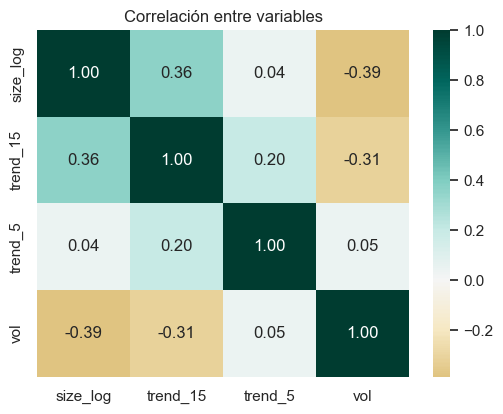

In [5]:
FEATS = ["size_log", "trend_15", "trend_5", "vol"]
lo, hi = feat[FEATS].quantile(0.05), feat[FEATS].quantile(0.95)
X = StandardScaler().fit_transform(feat[FEATS].clip(lo, hi, axis=1))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(feat[FEATS].corr(), annot=True, fmt=".2f", cmap="BrBG", center=0, ax=ax)
ax.set_title("Correlación entre variables")
plt.show()

## 2. ¿Cuántos grupos?
Se evalúan de 2 a 8 grupos con tres criterios: **inercia** (codo), **silhouette** (qué tan separados están) y **estabilidad bootstrap** (qué tanto cambian los grupos si se remuestrean los países; ARI mediano, 1 = idéntico).

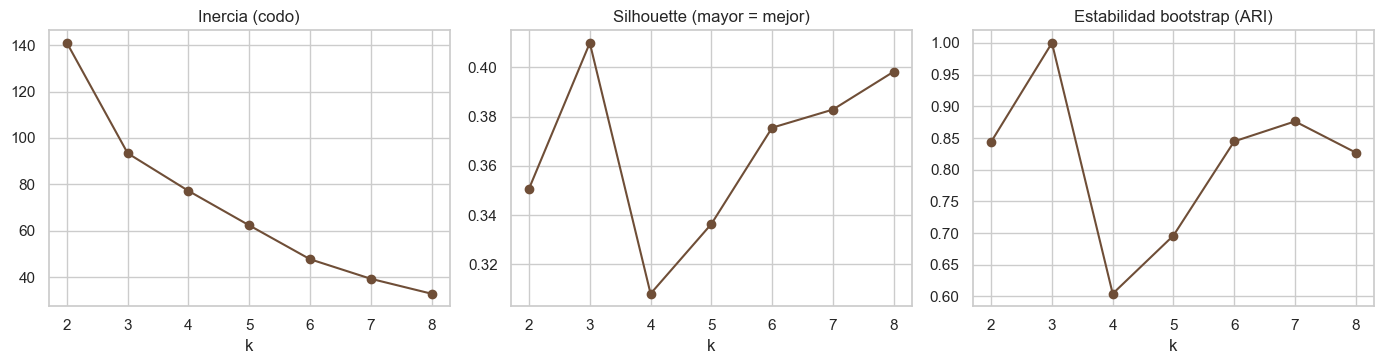

,inercia,silhouette,estabilidad_boot
k,,,
2,140.926,0.351,0.844
3,93.383,0.410,1.000
4,77.160,0.308,0.604
5,62.309,0.336,0.696
6,47.720,0.376,0.845
7,39.288,0.383,0.876
8,32.847,0.398,0.827


In [6]:
rng = np.random.default_rng(0)


def boot_ari(k, ref, n=100):
    out = []
    for b in range(n):
        idx = rng.choice(len(X), len(X), replace=True)
        lb = KMeans(n_clusters=k, n_init=10, random_state=b).fit(X[idx]).labels_
        out.append(adjusted_rand_score(ref[idx], lb))
    return float(np.median(out))


res = []
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, n_init=50, random_state=0).fit(X)
    res.append(dict(k=k, inercia=km_k.inertia_,
                    silhouette=silhouette_score(X, km_k.labels_),
                    estabilidad_boot=boot_ari(k, km_k.labels_)))
res = pd.DataFrame(res).set_index("k")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, col, t in zip(ax, ["inercia", "silhouette", "estabilidad_boot"],
                     ["Inercia (codo)", "Silhouette (mayor = mejor)", "Estabilidad bootstrap (ARI)"]):
    res[col].plot(ax=a, marker="o", color="#6f4e37"); a.set(title=t)
plt.tight_layout()
save_fig("seg_k")
plt.show()
res

**Decisión.** Estadísticamente, K=3 es el más "limpio", pero es poco útil: un solo grupo de 12 países reúne el 86% del consumo y mezcla a Brasil con mercados 10 veces más chicos. Con más de 6 grupos, 51 países quedan demasiado fragmentados. Se elige entonces el mejor silhouette **dentro del rango 4–6**; en ese rango también es donde la estabilidad bootstrap es más alta.

In [7]:
K = int(res.loc[4:6, "silhouette"].idxmax())
print(f"K elegido: {K}  (silhouette {res.loc[K, 'silhouette']:.2f}, estabilidad bootstrap {res.loc[K, 'estabilidad_boot']:.2f})")

K elegido: 6  (silhouette 0.38, estabilidad bootstrap 0.84)


## 3. Segmentación final y estabilidad
Un clustering solo sirve si es estable. Se comprueba de dos formas: (a) repetir KMeans con distintas semillas y (b) comparar con un método distinto (jerárquico de Ward). El **Adjusted Rand Index (ARI)** vale 1 si los grupos coinciden y ~0 si son independientes.

In [8]:
km = KMeans(n_clusters=K, n_init=50, random_state=0).fit(X)
ref = km.labels_

semillas = [adjusted_rand_score(ref, KMeans(n_clusters=K, n_init=1, random_state=s).fit(X).labels_)
            for s in range(1, 41)]
ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X).labels_

print(f"ARI entre semillas: mediana {np.median(semillas):.2f} (mín {np.min(semillas):.2f})")
print(f"ARI KMeans vs Ward: {adjusted_rand_score(ref, ward):.2f}")

ARI entre semillas: mediana 0.80 (mín 0.43)
ARI KMeans vs Ward: 0.42


**Lectura.** Los grupos son estables al remuestrear, pero solo moderadamente parecidos a los que arma Ward (jerárquico): la estructura de los datos no es de "islas" perfectamente separadas sino de un continuo, y las fronteras entre grupos pequeños son difusas. Por eso los grupos deben leerse como **etiquetas de trabajo**, no como categorías rígidas.

## 4. Perfil de cada grupo

In [9]:
feat["cluster"] = ref
peso = long[long.year == 2019].set_index("country")["consumption_m"]
feat["consumo_2019"] = peso.reindex(feat.index)

perfil = feat.groupby("cluster").agg(
    n_paises=("size_log", "size"),
    consumo_2019=("consumo_2019", "sum"),
    tamano_mediano=("consumo_2019", "median"),
    crec_largo_plazo=("trend_15", "median"),
    crec_reciente=("trend_5", "median"),
    volatilidad=("vol", "median"),
)
perfil["% del consumo"] = perfil["consumo_2019"] / perfil["consumo_2019"].sum() * 100
perfil["paises"] = feat.groupby("cluster").apply(
    lambda g: ", ".join(g.sort_values("consumo_2019", ascending=False).index[:6]) + (" …" if len(g) > 6 else ""))
perfil

,n_paises,consumo_2019,tamano_mediano,crec_largo_plazo,crec_reciente,volatilidad,% del consumo,paises
cluster,,,,,,,,
0,6,2.206,0.120,0.019,0.000,0.200,0.074,"Angola, Burundi, Ghana, Papua New Guinea, Gabo..."
1,19,320.880,12.960,0.002,-0.000,0.014,10.700,"India, Guatemala, Dominican Republic, Madagasc..."
2,8,"2,125.396",133.493,0.028,0.020,0.037,70.873,"Brazil, Indonesia, Ethiopia, Mexico, Colombia,..."
3,5,444.900,84.000,0.088,0.018,0.088,14.836,"Philippines, Vietnam, Thailand, Tanzania, Cent..."
4,10,4.020,0.300,-0.000,0.000,0.000,0.134,"Paraguay, Trinidad y Tobago, Jamaica, Guyana, ..."
5,3,101.460,21.120,-0.003,-0.058,0.087,3.383,"Venezuela, Costa Rica, Yemen"


## 5. Nombres de los grupos
Los nombres se asignan con reglas sobre el perfil (no a mano), para que se mantengan si se re-ejecuta el notebook: el grupo de mayor tamaño, el de mayor crecimiento de largo plazo, el de mayor caída reciente, el más volátil y el más pequeño.

In [10]:
def nombrar(perfil):
    nombres, libres = {}, set(perfil.index)

    def asignar(serie, nombre, fn):
        idx = getattr(perfil.loc[sorted(libres), serie], fn)()
        nombres[idx] = nombre
        libres.discard(idx)

    asignar("tamano_mediano", "Grandes en crecimiento sostenido", "idxmax")
    asignar("crec_largo_plazo", "Emergentes de alto crecimiento", "idxmax")
    asignar("crec_reciente", "En retroceso", "idxmin")
    asignar("volatilidad", "Pequeños volátiles", "idxmax")
    asignar("tamano_mediano", "Nicho plano", "idxmin")
    for i in libres:
        nombres[i] = "Maduros estancados"
    return nombres


NOMBRES = nombrar(perfil)
perfil.assign(segmento=perfil.index.map(NOMBRES))[["segmento", "n_paises", "% del consumo", "paises"]]

,segmento,n_paises,% del consumo,paises
cluster,,,,
0,Pequeños volátiles,6,0.074,"Angola, Burundi, Ghana, Papua New Guinea, Gabo..."
1,Maduros estancados,19,10.700,"India, Guatemala, Dominican Republic, Madagasc..."
2,Grandes en crecimiento sostenido,8,70.873,"Brazil, Indonesia, Ethiopia, Mexico, Colombia,..."
3,Emergentes de alto crecimiento,5,14.836,"Philippines, Vietnam, Thailand, Tanzania, Cent..."
4,Nicho plano,10,0.134,"Paraguay, Trinidad y Tobago, Jamaica, Guyana, ..."
5,En retroceso,3,3.383,"Venezuela, Costa Rica, Yemen"


## 6. Visualización

Varianza explicada por 2 componentes: 73%


c:\Users\danil\OneDrive\Documentos\GitHub\Prueba_NTT\utils.py:133: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")
c:\Users\danil\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


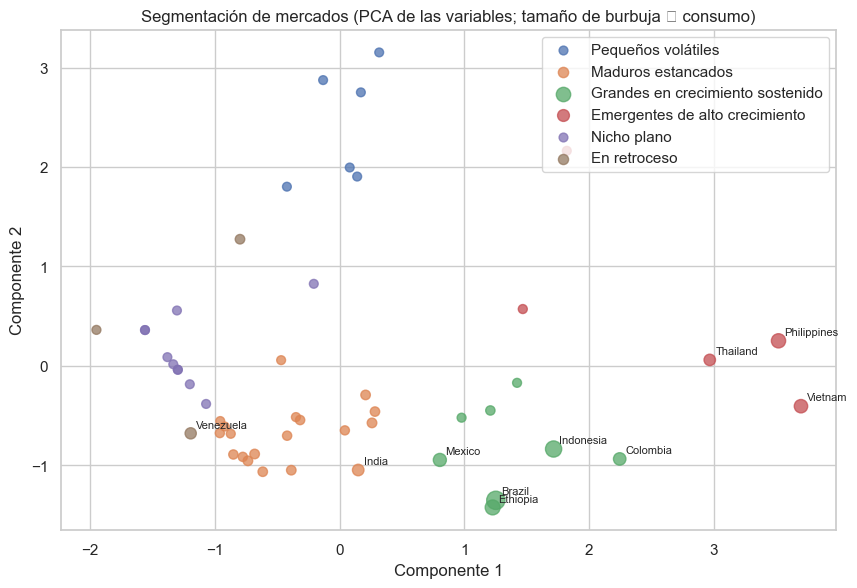

In [11]:
pca = PCA(n_components=2, random_state=0).fit(X)
Z = pca.transform(X)
feat["pc1"], feat["pc2"] = Z[:, 0], Z[:, 1]
print(f"Varianza explicada por 2 componentes: {pca.explained_variance_ratio_.sum():.0%}")

fig, ax = plt.subplots(figsize=(10, 6.5))
for cl, g in feat.groupby("cluster"):
    ax.scatter(g.pc1, g.pc2, s=40 + g.consumo_2019.clip(upper=400) / 3, alpha=0.75,
               label=NOMBRES.get(cl, f"Grupo {cl}"))
for c in feat.consumo_2019.nlargest(10).index:
    ax.annotate(c, (feat.loc[c, "pc1"], feat.loc[c, "pc2"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set(title="Segmentación de mercados (PCA de las variables; tamaño de burbuja ∝ consumo)",
       xlabel="Componente 1", ylabel="Componente 2")
ax.legend()
save_fig("seg_pca")
plt.show()

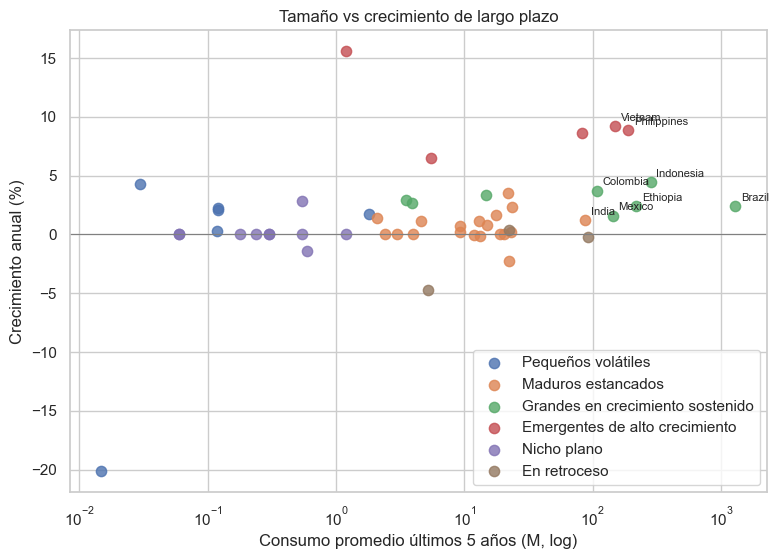

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
for cl, g in feat.groupby("cluster"):
    ax.scatter(10 ** g.size_log, g.trend_15 * 100, s=55, alpha=0.8, label=NOMBRES.get(cl, f"Grupo {cl}"))
for c in feat.consumo_2019.nlargest(8).index:
    ax.annotate(c, (10 ** feat.loc[c, "size_log"], feat.loc[c, "trend_15"] * 100), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log"); ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Tamaño vs crecimiento de largo plazo", xlabel="Consumo promedio últimos 5 años (M, log)", ylabel="Crecimiento anual (%)")
ax.legend()
save_fig("seg_tamano_crecimiento")
plt.show()

## 7. Guardar resultado

In [14]:
feat["segmento"] = feat["cluster"].map(NOMBRES)
feat[["cluster", "segmento"] + FEATS + ["consumo_2019"]].reset_index().to_parquet(OUT / "segments.parquet", index=False)

tabla = (feat.reset_index().sort_values("consumo_2019", ascending=False)
             .groupby("segmento")["country"].apply(lambda s: ", ".join(s)).to_frame("países"))
pd.set_option("display.max_colwidth", None)
tabla

,países
segmento,
Emergentes de alto crecimiento,"Philippines, Vietnam, Thailand, Tanzania, Central African Republic"
En retroceso,"Venezuela, Costa Rica, Yemen"
Grandes en crecimiento sostenido,"Brazil, Indonesia, Ethiopia, Mexico, Colombia, Uganda, Kenya, Bolivia"
Maduros estancados,"India, Guatemala, Dominican Republic, Madagascar, Honduras, Haiti, Côte d'Ivoire, El Salvador, Peru, Cuba, Nicaragua, RD Congo, Laos, Ecuador, Cameroon, Panama, Guinea, Nigeria, Sri Lanka"
Nicho plano,"Paraguay, Trinidad y Tobago, Guyana, Jamaica, Sierra Leone, Liberia, Zimbabwe, Congo, Rwanda, Malawi"
Pequeños volátiles,"Angola, Papua New Guinea, Burundi, Ghana, Gabon, Togo"


## 8. Conclusiones

1. **Seis segmentos.** K=6 tiene el mejor silhouette en el rango 4–6 (0.38) y estabilidad bootstrap de 0.84. La coincidencia con Ward es moderada (ARI 0.42): los segmentos son etiquetas de trabajo, no fronteras rígidas.
2. **Grandes en crecimiento sostenido** (8 países, 71% del consumo): Brasil, Indonesia, Etiopía, México, Colombia, Uganda, Kenia y Bolivia. Crecen ~2.8% anual con baja volatilidad. Es donde está el volumen.
3. **Emergentes de alto crecimiento** (5 países, 15% del consumo): Filipinas, Vietnam, Tailandia, Tanzania y República Centroafricana. Crecieron ~8.8% anual en 15 temporadas, pero solo ~1.8% mediano en las últimas 5 (Vietnam 3.6%, Filipinas 2.5%, Tailandia 1.8%): **se están desacelerando**. Extrapolar su historia larga sería optimista.
4. **Maduros estancados** (19 países, 11%): crecimiento cercano a cero. Incluye a India, Guatemala, República Dominicana y Perú.
5. **En retroceso** (Venezuela, Costa Rica, Yemen; 3.4%): caen ~5.8% anual en las últimas 5 temporadas.
6. **Nicho plano** (10) y **Pequeños volátiles** (6): juntos suman 0.2% del consumo. Sin relevancia comercial, y muchas de sus series son planas (probablemente estimadas).

**Siguiente:** `04_opportunity.ipynb` combina este resultado con el pronóstico del notebook 02.